# 1. Импорты и настройка

In [2]:
import torch
import numpy as np
import pandas as pd
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

torch: 2.12.0.dev20260408+cu128 | CUDA: True


In [1]:
from datasets import load_dataset

d:\Shared\Documents\Уник\NLP\Project\.venv_NLP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from transformers import pipeline, BitsAndBytesConfig
print("ok")

ok


### Системный промпт 

In [4]:
SYSTEM_PROMPT = """You are a Python coding assistant.
Always end your response with the final implementation inside triple backticks, and nothing after it:

```python
# your code here
```
"""

### Отключение warnings 

In [5]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

### Random seed

Зафиксируем Seed для воспроизводимости эксперимента 

In [6]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 2. Загрузка моделей (7B и 1.5B)

## Qwen2.5-Coder-7B-Instruct

In [7]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype="bfloat16",
)

pipe = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-Coder-7B-Instruct",
    model_kwargs={"quantization_config": quant_config},
    device_map="auto",
)

W0517 00:40:09.288000 3052 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights: 100%|██████████| 339/339 [00:35<00:00,  9.50it/s]


## Qwen2.5-Coder-1.5B-Instruct

In [8]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype="bfloat16",
)

pipe_small = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-Coder-1.5B-Instruct",
    model_kwargs={"quantization_config": quant_config},
    device_map="auto",
)

Loading weights: 100%|██████████| 338/338 [00:07<00:00, 46.63it/s]


# 3. Загрузка датасета

In [9]:
ds = load_dataset("openai_humaneval")

In [10]:
df = pd.DataFrame(ds['test'])

## Структура датасета

In [11]:
df.head()

,task_id,prompt,canonical_solution,test,entry_point
0,HumanEval/0,from typing import List\n\n\ndef has_close_ele...,"for idx, elem in enumerate(numbers):\n ...","\n\nMETADATA = {\n 'author': 'jt',\n 'da...",has_close_elements
1,HumanEval/1,from typing import List\n\n\ndef separate_pare...,result = []\n current_string = []\n ...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",separate_paren_groups
2,HumanEval/2,\n\ndef truncate_number(number: float) -> floa...,return number % 1.0\n,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",truncate_number
3,HumanEval/3,from typing import List\n\n\ndef below_zero(op...,balance = 0\n\n for op in operations:\n...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",below_zero
4,HumanEval/4,from typing import List\n\n\ndef mean_absolute...,mean = sum(numbers) / len(numbers)\n re...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",mean_absolute_deviation


# 4. Вспомогательные функции


In [12]:
def extract_code(text):
    blocks = re.findall(r"```python\n(.*?)```", text, re.DOTALL)
    if not blocks:
        return text
    
    code = blocks[-1]

    # Убираем строки после конца функции (print, тесты и тд)
    lines = code.split('\n')
    clean_lines = []
    for line in lines:
        if line.startswith("print(") or line.startswith("# Test"):
            break
        clean_lines.append(line)

    return "\n".join(clean_lines)

In [13]:
def run_test(generated_code, test, entry_point):
    try:
        # выполняю код ген
        exec_globals = {}
        exec(generated_code, exec_globals)

        # candidate- функция, прогоняем тесты
        exec(test, exec_globals)
        exec_globals["check"](exec_globals[entry_point])

        return True
    except Exception:
        return False

# Эксперименты

## Zero-Shot

In [43]:
models = {
    "7B" : pipe,
    "1.5B" : pipe_small
}

results_zero_shot = {name: {True: [], False: []} for name in models}

for i in tqdm(range(len(df)), desc='Zero-Shot'):
    prompt = df.iloc[i].prompt
    message = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
    ]
 
    for name, model in models.items():
        result = run_test(
            generated_code=extract_code(model(message, max_new_tokens=512)[0]["generated_text"][-1]["content"]),
            test=df.iloc[i].test,
            entry_point=df.iloc[i].entry_point)
        results_zero_shot[name][result].append(i)

Zero-Shot:  30%|███       | 50/164 [12:40<29:47, 15.68s/it] 

All tests passed!


Zero-Shot: 100%|██████████| 164/164 [47:15<00:00, 17.29s/it]


### Результаты Zero-shot

In [ ]:
for name in models:
    total = len(df)
    correct = len(results_zero_shot[name][True])
    print(f"{name}: {correct}/{total} ({correct/total*100:.1f}%)")

NameError: name 'results' is not defined

## Few-shot

In [18]:
def make_few_shot_messages(df, target_idx, k=3):
    # Берём k примеров - любые задачи кроме текущей
    examples = df[df.index != target_idx].sample(k)
    
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    
    # Добавляем примеры как пары user/assistant
    for _, ex in examples.iterrows():
        messages.append({"role": "user", "content": ex.prompt})
        messages.append({"role": "assistant", "content": f"```python\n{ex.prompt}{ex.canonical_solution}\n```"})
    
    # Добавляем основную задачу
    messages.append({"role": "user", "content": df.iloc[target_idx].prompt})
    
    return messages

In [23]:
from tqdm import tqdm

models = {
    "7B": pipe,
    "1.5B": pipe_small
}
ks = [1, 3, 5]
results_few_shot = {k: {name: {True: [], False: []} for name in models} for k in ks}

for k in ks:
    for i in tqdm(range(len(df)), desc=f"Few-shot k={k}"):
        messages = make_few_shot_messages(df, target_idx=i, k=k)
        for name, model in models.items():
            result = run_test(
                generated_code=extract_code(model(messages, max_new_tokens=512)[0]["generated_text"][-1]["content"]),
                test=df.iloc[i].test,
                entry_point=df.iloc[i].entry_point
            )
            results_few_shot[k][name][result].append(i)

for k in ks:
    print(f"\nFew-shot k={k}:")
    for name in models:
        correct = len(results_few_shot[k][name][True])
        print(f"  {name}: {correct}/164 ({correct/164*100:.1f}%)")

Few-shot k=5:  20%|█▉        | 32/164 [8:46:47<36:13:00, 987.73s/it]


KeyboardInterrupt: 

In [25]:
from tqdm import tqdm

k = 5
for i in tqdm(range(32, len(df)), desc=f"k={k}"):
    messages = make_few_shot_messages(df, target_idx=i, k=k)
    for name, model in models.items():
        result = run_test(
            generated_code=extract_code(model(messages, max_new_tokens=512)[0]["generated_text"][-1]["content"]),
            test=df.iloc[i].test,
            entry_point=df.iloc[i].entry_point
        )
        results_few_shot[k][name][result].append(i)

for name in models:
    true_count = len(results_few_shot[k][name][True])
    print(f"{name}: {true_count}/164 ({true_count/164*100:.1f}%)")

k=5: 100%|██████████| 132/132 [1:45:33<00:00, 47.98s/it]  

7B: 140/164 (85.4%)
1.5B: 85/164 (51.8%)


Почему-то при k = 5 на задаче 32 торч ломается, и контекст перегружается. Поэтому пришлось пройтись отдельно для k = 5. Посмотрим на результаты. 

In [26]:
for k in ks:
    print(f"\nFew-shot k={k}:")
    for name in models:
        correct = len(results_few_shot[k][name][True])
        print(f"  {name}: {correct}/164 ({correct/164*100:.1f}%)")


Few-shot k=1:
  7B: 141/164 (86.0%)
  1.5B: 93/164 (56.7%)

Few-shot k=3:
  7B: 140/164 (85.4%)
  1.5B: 97/164 (59.1%)

Few-shot k=5:
  7B: 140/164 (85.4%)
  1.5B: 85/164 (51.8%)


## Chain of Thought

### Функция для добавления просьбы "порассуждать" модель

In [27]:
def make_cot_message(prompt):
    # К промпту также добавляем просьбу "порассуждать" модель по шагам    
    message = [{"role": "user", "content": prompt + '\nFirst, think step by step about the alghoritm, then write a code.'},
                {"role": "system", "content" : SYSTEM_PROMPT}]
    
    return message

In [30]:
models = {
    "7B": pipe,
    "1.5B": pipe_small
}

results_cot = {name : {True: [], False: []} for name in models}

for i in tqdm(range(len(df)), desc='CoT'):
    prompt = df.iloc[i].prompt
    message = make_cot_message(prompt)
    for name, model in models.items():
        result = run_test(
            generated_code=extract_code(model(message, max_new_tokens=512)[0]["generated_text"][-1]["content"]),
            test=df.iloc[i].test,
            entry_point=df.iloc[i].entry_point
        )

        results_cot[name][result].append(i)

for name in models:
    correct = len(results_cot[name][True])
    print(f"{name}: {correct}/164 ({correct/164*100:.1f}%)")

CoT: 100%|██████████| 164/164 [1:22:31<00:00, 30.19s/it]

7B: 122/164 (74.4%)
1.5B: 84/164 (51.2%)


# RAG

In [33]:
from sentence_transformers import SentenceTransformer

In [34]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4407.85it/s]


In [35]:
prompts = df.prompt.to_list()

In [36]:
embeddings = embedder.encode(prompts, show_progress_bar=True)

Batches: 100%|██████████| 6/6 [00:00<00:00, 12.45it/s]


In [37]:
import faiss
import numpy as np

embeddings_np = np.array(embeddings).astype("float32")
index = faiss.IndexFlatL2(embeddings_np.shape[1])
index.add(embeddings_np)

In [38]:
def make_rag_messages(df, target_idx, k=3):
    # Берем вектор текущей задачи
    query = embeddings_np[target_idx].reshape(1, -1)

    # Ищем k+1 ближайщих (первый самый близкий вектор - сама задача)
    distance, indices = index.search(query, k + 1)

    # Убираем саму задачу из результатов поиска
    similar_inices = [idx for idx in indices[0] if idx != target_idx][:k]

    messages = [{"role": "system", "content" : SYSTEM_PROMPT}]

    # Добавляем похожие задачи как примеры
    for idx in similar_inices:
        ex = df.iloc[idx]
        messages.append({"role" : "user", "content": ex.prompt})
        messages.append({"role": "assistant", "content": f"```python\n{ex.prompt}{ex.canonical_solution}\n```"})

    messages.append({"role": "user", "content": df.iloc[target_idx].prompt})

    return messages

    

In [42]:
results_rag = {model: {True: [], False: []} for model in models}

for i in tqdm(range(len(df)), desc = "RAG"):
    messages = make_rag_messages(df, target_idx=i, k = 3)
    for name, model in models.items():
        result = run_test(
            generated_code=extract_code(model(messages, max_new_tokens=512)[0]["generated_text"][-1]["content"]),
            test=df.iloc[i].test,
            entry_point=df.iloc[i].entry_point
        )
        results_rag[name][result].append(i)


for name in models:
    correct = len(results_rag[name][True])
    print(f"{name}: {correct}/164 ({correct/164*100:.1f}%)")

RAG: 100%|██████████| 164/164 [48:43<00:00, 17.83s/it]

7B: 140/164 (85.4%)
1.5B: 85/164 (51.8%)


# Анализ ошибок

Посмотрим где провалились обе модели

In [45]:
failed_7b = set(results_zero_shot["7B"][False])

failed_15b = set(results_zero_shot["1.5B"][False])

both_failed = failed_7b & failed_15b

print(f"Провалились обе модели: {len(both_failed)} задач")
print(f"Индексы: {sorted(both_failed)}")

Провалились обе модели: 21 задач
Индексы: [10, 17, 26, 32, 38, 50, 83, 95, 108, 115, 126, 127, 129, 130, 132, 134, 135, 141, 142, 145, 163]


Теперь рассмотрим пару прмиеров данных задач

In [46]:
for idx in [10, 17, 26]:
    print(f"\n{'='*50}")
    print(f"Задача #{idx}")
    print(f"{'='*50}")
    print(df.iloc[idx].prompt)


Задача #10


def is_palindrome(string: str) -> bool:
    """ Test if given string is a palindrome """
    return string == string[::-1]


def make_palindrome(string: str) -> str:
    """ Find the shortest palindrome that begins with a supplied string.
    Algorithm idea is simple:
    - Find the longest postfix of supplied string that is a palindrome.
    - Append to the end of the string reverse of a string prefix that comes before the palindromic suffix.
    >>> make_palindrome('')
    ''
    >>> make_palindrome('cat')
    'catac'
    >>> make_palindrome('cata')
    'catac'
    """


Задача #17
from typing import List


def parse_music(music_string: str) -> List[int]:
    """ Input to this function is a string representing musical notes in a special ASCII format.
    Your task is to parse this string and return list of integers corresponding to how many beats does each
    not last.

    Here is a legend:
    'o' - whole note, lasts four beats
    'o|' - half note, lasts two beats
 

Посмотрим что модели генерируют для данных задач.

In [47]:
for idx in [10, 17, 26]:
    print(f"\n{'='*50}")
    print(f"Задача #{idx}")
    print(f"{'='*50}")
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": df.iloc[idx].prompt}
    ]
    raw = pipe(messages, max_new_tokens=512)[0]["generated_text"][-1]["content"]
    code = extract_code(raw)
    print(code)
    print(f"\nТест пройден: {run_test(code, df.iloc[idx].test, df.iloc[idx].entry_point)}")


Задача #10
def is_palindrome(string: str) -> bool:
    """ Test if given string is a palindrome """
    return string == string[::-1]


def make_palindrome(string: str) -> str:
    """ Find the shortest palindrome that begins with a supplied string.
    Algorithm idea is simple:
    - Find the longest postfix of supplied string that is a palindrome.
    - Append to the end of the string reverse of a string prefix that comes before the palindromic suffix.
    >>> make_palindrome('')
    ''
    >>> make_palindrome('cat')
    'catac'
    >>> make_palindrome('cata')
    'catac'
    """
    for i in range(len(string), -1, -1):
        if is_palindrome(string[i:]):
            return string + string[:i][::-1]
    return string  # In case the entire string is a palindrome


Тест пройден: False

Задача #17
from typing import List

def parse_music(music_string: str) -> List[int]:
    # Define a dictionary to map the music symbols to their corresponding beat counts
    symbol_to_beat = {
      

Для задачи 10 код логически правильный, скорее всего падает на граничном случае. 

Для задачи 17 тест пройден, значит это просто ошибка генерации.

Для задачи 26 модель неправильно поняла задачу. Задание говорит убрать элементы которые встречаются *более одного раза*, а модель написала убрать *дубликаты* оставляя первое вхождение. Это ошибка непонимания условия. 

Рассмотрим код, который написала модель для задачи 10. 

In [49]:
def is_palindrome(string: str) -> bool:
    """ Test if given string is a palindrome """
    return string == string[::-1]


def make_palindrome(string: str) -> str:
    """ Find the shortest palindrome that begins with a supplied string.
    Algorithm idea is simple:
    - Find the longest postfix of supplied string that is a palindrome.
    - Append to the end of the string reverse of a string prefix that comes before the palindromic suffix.
    >>> make_palindrome('')
    ''
    >>> make_palindrome('cat')
    'catac'
    >>> make_palindrome('cata')
    'catac'
    """
    for i in range(len(string), -1, -1):
        if is_palindrome(string[i:]):
            return string + string[:i][::-1]
    return string  # In case the entire string is a palindrome

test_palindrome = make_palindrome('cat')

print(test_palindrome)

cattac


Суть задачи — дополнить строку минимальным количеством символов справа, чтобы получился палиндром. Например 'cat' - необходимо дописать строку 'ac', чтоб получилось 'catac'. 

Из примера, который я привел выше видно, что модель не справилась. Вместо того, чтобы дописать 'ac', дописала то же слово наоборот, что удлинило палиндром на 1 символ, по сравнению с правильным решением. 

Проблема в направлении цикла, модель идет от конца к началу:

```
for i in range(len(string), -1, -1): При 'cat':
```

* Первая же итерация: i=3 → string[3:] = '' → пустая строка всегда палиндром
* Сразу возвращает 'cat' + 'tac' = 'cattac', что неверно

Цикл должен идти в обратную сторону — от 0, чтобы сначала проверять длинные суффиксы:

```
for i in range(len(string) + 1):
```

Тогда для 'cat':

* i=0 → 'cat' → не палиндром
* i=1 → 'at' → не палиндром
* i=2 → 't' → палиндром → 'cat' + 'ac' = 'catac' ✓

Посмотрим еще 1 задачу из тех, которые модель не смогла решить верно.

In [50]:
print(df.iloc[38].prompt)



def encode_cyclic(s: str):
    """
    returns encoded string by cycling groups of three characters.
    """
    # split string to groups. Each of length 3.
    groups = [s[(3 * i):min((3 * i + 3), len(s))] for i in range((len(s) + 2) // 3)]
    # cycle elements in each group. Unless group has fewer elements than 3.
    groups = [(group[1:] + group[0]) if len(group) == 3 else group for group in groups]
    return "".join(groups)


def decode_cyclic(s: str):
    """
    takes as input string encoded with encode_cyclic function. Returns decoded string.
    """



Посмотрим, что написала модель.

In [51]:
messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": df.iloc[38].prompt}
]
raw = pipe(messages, max_new_tokens=512)[0]["generated_text"][-1]["content"]
code = extract_code(raw)
print(code)
print(f"\nТест пройден: {run_test(code, df.iloc[38].test, df.iloc[38].entry_point)}")

def decode_cyclic(s: str):
    """
    takes as input string encoded with encode_cyclic function. Returns decoded string.
    """
    # split string to groups. Each of length 3.
    groups = [s[(3 * i):min((3 * i + 3), len(s))] for i in range((len(s) + 2) // 3)]
    # reverse the cycle elements in each group. Unless group has fewer elements than 3.
    groups = [(group[-1] + group[:-1]) if len(group) == 3 else group for group in groups]
    return "".join(groups)


Тест пройден: False


Задача #26 (remove_duplicates)

Суть задачи — удалить из списка все элементы, которые встречаются более одного раза. При этом порядок оставшихся элементов должен сохраниться. Например `[1, 2, 3, 2, 4]` → `[1, 3, 4]` (двойка встретилась дважды — убираем оба вхождения).

Модель сгенерировала следующий код:

```python
seen = set()
result = []
for number in numbers:
    if number not in seen:
        seen.add(number)
        result.append(number)
return result
```

Это классический алгоритм удаления дубликатов с сохранением первого вхождения. Для `[1, 2, 3, 2, 4]` он вернёт `[1, 2, 3, 4]`, тогда как правильный ответ `[1, 3, 4]`. Модель решила похожую, но другую задачу — неправильно интерпретировала условие "remove all elements that occur more than once". Правильное решение требует предварительного подсчёта частоты каждого элемента.

Задача #38 (decode_cyclic)

Суть задачи — написать функцию обратную к `encode_cyclic`, которая сдвигает каждую тройку символов влево: `ABC → BCA`. Декодирование должно делать обратный сдвиг — вправо: `BCA → ABC`.

Модель сгенерировала:

```python
groups = [(group[-1] + group[:-1]) if len(group) == 3 else group for group in groups]
```

Это математически верное решение — `group[-1] + group[:-1]` для `BCA` даёт `ABC`. Однако тест не проходит. Причина не в логике модели, а в артефакте системы оценки — функция `encode_cyclic` уже определена в промпте, и при `exec` она переопределяется, что может вызывать конфликт при выполнении тестов. Это пример случая когда система оценки засчитывает ошибку там, где модель на самом деле справилась с задачей.



## Рассмотрим результаты более подробно

### Сравнений стратегий по моделям

[0 1 2 3 4 5]


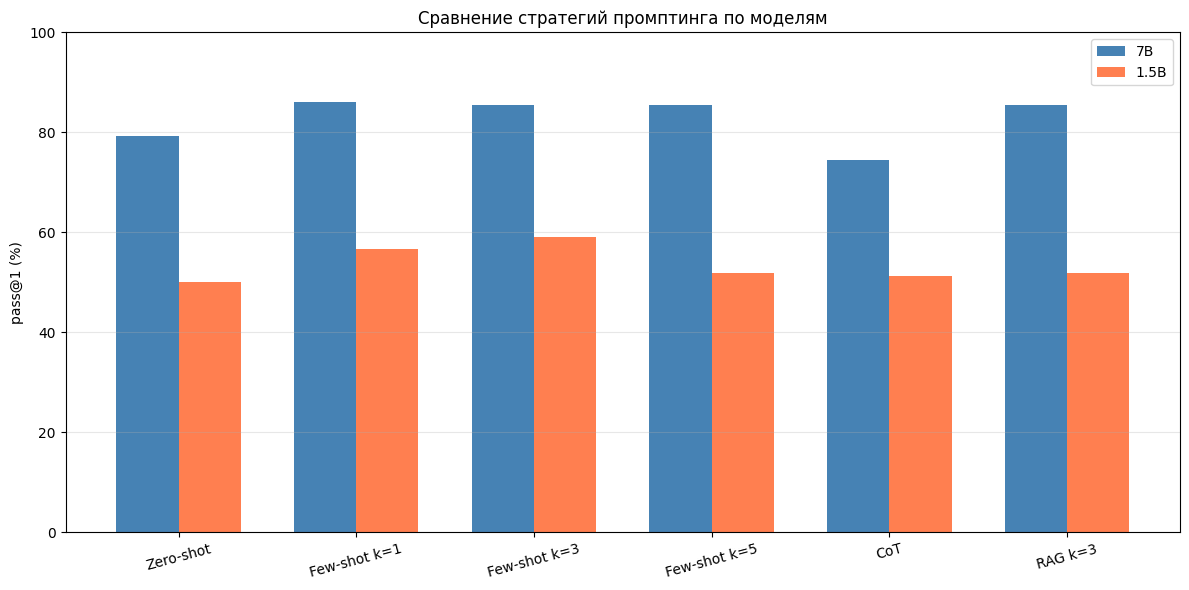

In [5]:
# Стратегии, которые использовались
strategies = ['Zero-shot', 'Few-shot k=1', 'Few-shot k=3', 'Few-shot k=5', 'CoT', 'RAG k=3']
# Результаты для Qwen 7B (в процентах)
results_7b = [79.3, 86.0, 85.4, 85.4, 74.4, 85.4]
# Результаты для Qwen 1.5B (в процентах)
results_15b = [50.0, 56.7, 59.1, 51.8, 51.2, 51.8]

x = np.arange(len(strategies))

print(x)
width = 0.35

fig, ax = plt.subplots(figsize = (12, 6))
ax.bar(x - width/2, results_7b, width, label='7B', color='steelblue')
ax.bar(x + width/2, results_15b, width, label='1.5B', color='coral')\

ax.set_ylabel('pass@1 (%)')
ax.set_title('Сравнение стратегий промптинга по моделям')
ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=15)
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### График зависимости от k в few-shot

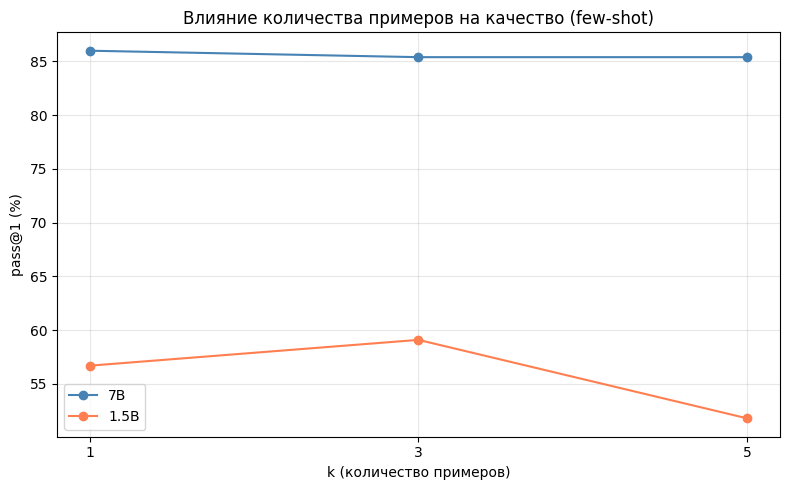

In [6]:
ks = [1, 3, 5]
few_shot_7b = [86.0, 85.4, 85.4]
few_shot_15b = [56.7, 59.1, 51.8]

plt.figure(figsize=(8, 5))
plt.plot(ks, few_shot_7b, 'o-', label='7B', color='steelblue')
plt.plot(ks, few_shot_15b, 'o-', label='1.5B', color='coral')
plt.xlabel('k (количество примеров)')
plt.ylabel('pass@1 (%)')
plt.title('Влияние количества примеров на качество (few-shot)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(ks)
plt.tight_layout()
plt.show()

Из графиков видно:
* 7B стабильно лучше 1.5B на 25-30% по всем стратегиям;
* 7B практически не реагирует на количество примеров - линия практически горизонтальная (для few-shot)
* 1.5B пик качества при k = 3, потом падает - слишком много контекста вредит очень маленькой модели
* CoT худший для 7B, но почти не влияет на 1.5B